In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [72]:
df = pd.read_csv("C:\\Users\\AMAN KUMAR VERMA\\Downloads\\fastapi_projects\\bfsi_loan_default_data.csv")
df.head()

,customer_id,application_date,age,gender,marital_status,education,num_dependents,city_tier,employment_type,annual_income,account_tenure_years,num_credit_cards,credit_score,has_defaulted_before,existing_loans_count,loan_purpose,loan_amount,loan_tenure_months,interest_rate,monthly_expenses,collateral_value,loan_default
0,CUST104141,2025-03-27,56,Male,Married,Graduate,0,Tier 2,Salaried,365827.0,0.2,1.0,759.0,0,1,Personal,52600.0,48,14.18,8474.0,NaN,0
1,CUST103625,2025-10-23,28,Female,Married,High School,5,Tier 2,Salaried,554629.0,0.5,2.0,689.0,1,0,Auto,135000.0,120,8.70,20451.0,172563.0,1
2,CUST108279,2025-08-13,50,Male,Single,High School,3,Tier 1,Self-Employed,599645.0,1.7,2.0,616.0,0,2,Auto,116200.0,24,10.14,23777.0,150291.0,0
3,CUST103903,2025-09-20,28,Male,Divorced,Graduate,2,Tier 1,Business Owner,813436.0,NaN,2.0,585.0,0,1,Business,45700.0,48,8.15,22417.0,NaN,0
4,CUST102573,2024-02-21,37,Male,Widowed,High School,2,Tier 1,Business Owner,389275.0,1.2,3.0,635.0,0,0,Business,123900.0,48,8.65,17214.0,NaN,1


In [73]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [74]:
df.head()

,customer_id,application_date,age,gender,marital_status,education,num_dependents,city_tier,employment_type,annual_income,account_tenure_years,num_credit_cards,credit_score,has_defaulted_before,existing_loans_count,loan_purpose,loan_amount,loan_tenure_months,interest_rate,monthly_expenses,collateral_value,loan_default
0,CUST104141,2025-03-27,56,Male,Married,Graduate,0,Tier 2,Salaried,365827.0,0.2,1.0,759.0,0,1,Personal,52600.0,48,14.18,8474.0,NaN,0
1,CUST103625,2025-10-23,28,Female,Married,High School,5,Tier 2,Salaried,554629.0,0.5,2.0,689.0,1,0,Auto,135000.0,120,8.70,20451.0,172563.0,1
2,CUST108279,2025-08-13,50,Male,Single,High School,3,Tier 1,Self-Employed,599645.0,1.7,2.0,616.0,0,2,Auto,116200.0,24,10.14,23777.0,150291.0,0
3,CUST103903,2025-09-20,28,Male,Divorced,Graduate,2,Tier 1,Business Owner,813436.0,NaN,2.0,585.0,0,1,Business,45700.0,48,8.15,22417.0,NaN,0
4,CUST102573,2024-02-21,37,Male,Widowed,High School,2,Tier 1,Business Owner,389275.0,1.2,3.0,635.0,0,0,Business,123900.0,48,8.65,17214.0,NaN,1


In [75]:
df.shape

(10015, 22)

In [76]:
df.drop_duplicates(inplace=True)

In [77]:
df.shape

(10000, 22)

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 10014
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           10000 non-null  object 
 1   application_date      10000 non-null  object 
 2   age                   10000 non-null  int64  
 3   gender                10000 non-null  object 
 4   marital_status        10000 non-null  object 
 5   education             9900 non-null   object 
 6   num_dependents        10000 non-null  int64  
 7   city_tier             10000 non-null  object 
 8   employment_type       10000 non-null  object 
 9   annual_income         9700 non-null   float64
 10  account_tenure_years  9750 non-null   float64
 11  num_credit_cards      9850 non-null   float64
 12  credit_score          9800 non-null   float64
 13  has_defaulted_before  10000 non-null  int64  
 14  existing_loans_count  10000 non-null  int64  
 15  loan_purpose          10

In [79]:
100*df.isnull().sum()/len(df)

customer_id              0.00
application_date         0.00
age                      0.00
gender                   0.00
marital_status           0.00
education                1.00
num_dependents           0.00
city_tier                0.00
employment_type          0.00
annual_income            3.00
account_tenure_years     2.50
num_credit_cards         1.50
credit_score             2.00
has_defaulted_before     0.00
existing_loans_count     0.00
loan_purpose             0.00
loan_amount              0.00
loan_tenure_months       0.00
interest_rate            0.00
monthly_expenses         2.00
collateral_value        53.51
loan_default             0.00
dtype: float64

In [80]:
df.drop(['collateral_value','customer_id','application_date'], axis=1, inplace=True)

In [81]:
# filling missing values with mean for numerical columns and mode for categorical columns
df = df.fillna(df.mean(numeric_only=True))
df = df.fillna(df.mode().iloc[0])


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 10014
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   10000 non-null  int64  
 1   gender                10000 non-null  object 
 2   marital_status        10000 non-null  object 
 3   education             10000 non-null  object 
 4   num_dependents        10000 non-null  int64  
 5   city_tier             10000 non-null  object 
 6   employment_type       10000 non-null  object 
 7   annual_income         10000 non-null  float64
 8   account_tenure_years  10000 non-null  float64
 9   num_credit_cards      10000 non-null  float64
 10  credit_score          10000 non-null  float64
 11  has_defaulted_before  10000 non-null  int64  
 12  existing_loans_count  10000 non-null  int64  
 13  loan_purpose          10000 non-null  object 
 14  loan_amount           10000 non-null  float64
 15  loan_tenure_months    10

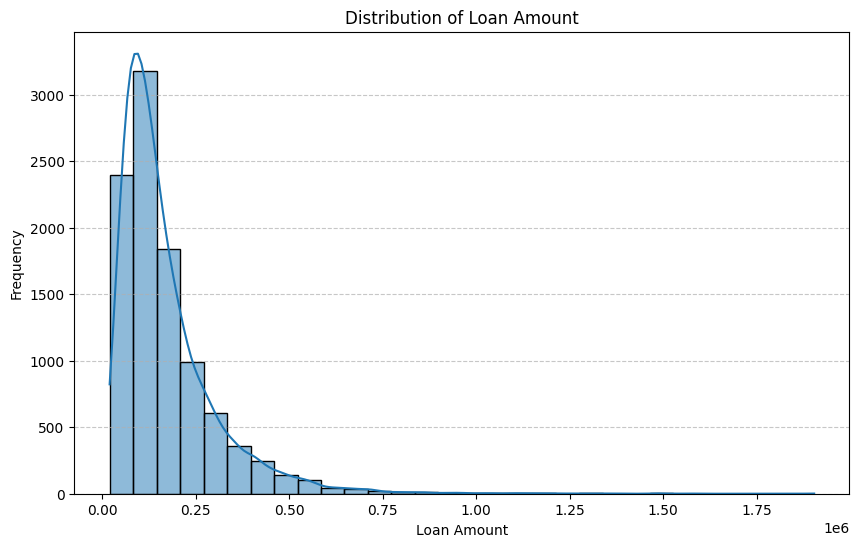

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['loan_amount'], bins=30, kde=True)
plt.title('Distribution of Loan Amount')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [84]:
df.dtypes

age                       int64
gender                   object
marital_status           object
education                object
num_dependents            int64
city_tier                object
employment_type          object
annual_income           float64
account_tenure_years    float64
num_credit_cards        float64
credit_score            float64
has_defaulted_before      int64
existing_loans_count      int64
loan_purpose             object
loan_amount             float64
loan_tenure_months        int64
interest_rate           float64
monthly_expenses        float64
loan_default              int64
dtype: object

In [85]:
# one hot encoding for categorical variables

import pandas as pd

# 1. Automatically convert all object/category columns to One-Hot Encodings
# drop_first=True is CRITICAL to avoid the Dummy Variable Trap & Matrix Singularity!
df_encoded = pd.get_dummies(
    df, 
    columns=df.select_dtypes(include=['object', 'category']).columns, 
    drop_first=True, 
    dtype=float
)

In [86]:
df_encoded.head()

,age,num_dependents,annual_income,account_tenure_years,num_credit_cards,credit_score,has_defaulted_before,existing_loans_count,loan_amount,loan_tenure_months,interest_rate,monthly_expenses,loan_default,gender_Male,gender_Other,marital_status_Married,marital_status_Single,marital_status_Widowed,education_Graduate,education_High School,education_Post Graduate,city_tier_Tier 2,city_tier_Tier 3,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed,loan_purpose_Business,loan_purpose_Education,loan_purpose_Gold,loan_purpose_Home,loan_purpose_Personal
0,56,0,365827.0,0.200000,1.0,759.0,0,1,52600.0,48,14.18,8474.0,0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,28,5,554629.0,0.500000,2.0,689.0,1,0,135000.0,120,8.70,20451.0,1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,50,3,599645.0,1.700000,2.0,616.0,0,2,116200.0,24,10.14,23777.0,0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,28,2,813436.0,4.010021,2.0,585.0,0,1,45700.0,48,8.15,22417.0,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,37,2,389275.0,1.200000,3.0,635.0,0,0,123900.0,48,8.65,17214.0,1,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [87]:
# splite the data into features and target variable
x = df_encoded.drop('loan_default', axis=1)
y= df_encoded['loan_default']

In [88]:
# train test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [89]:
# check the shape of the train and test sets
print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

x_train shape: (8000, 30)
x_test shape: (2000, 30)
y_train shape: (8000,)
y_test shape: (2000,)


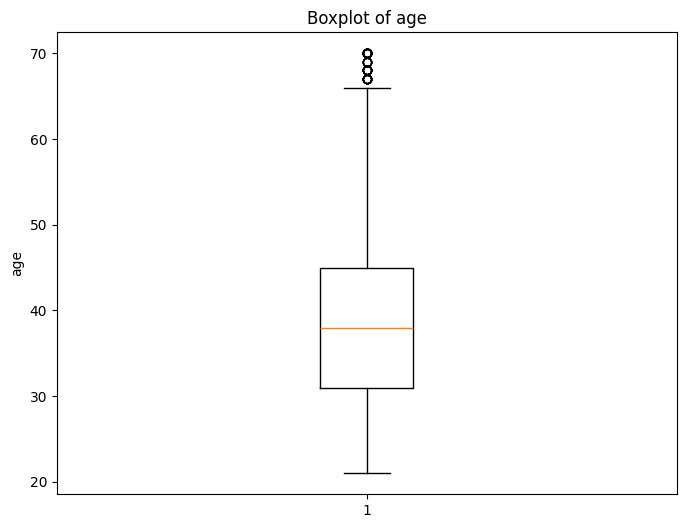

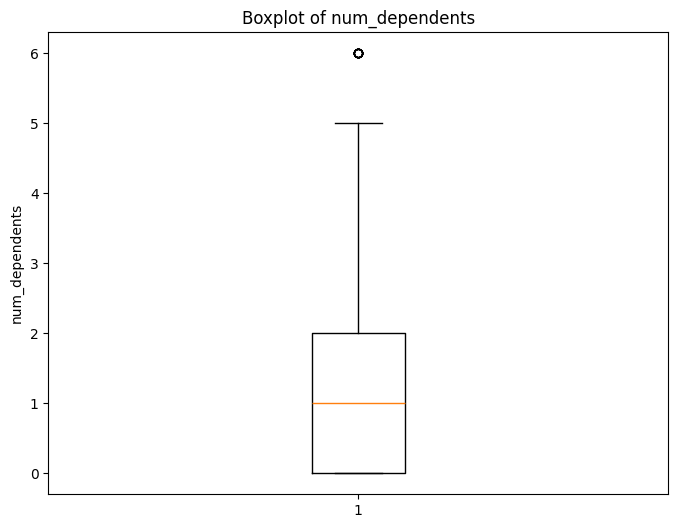

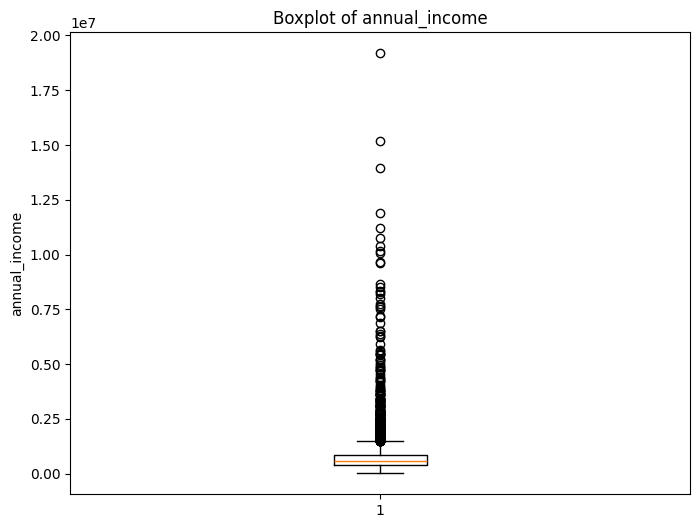

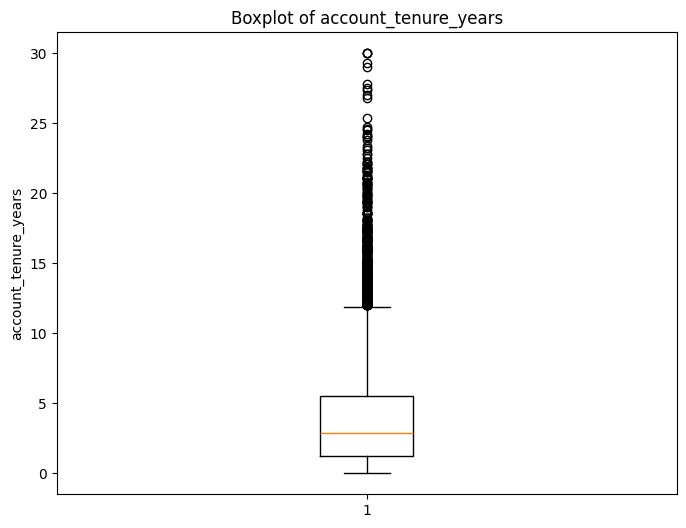

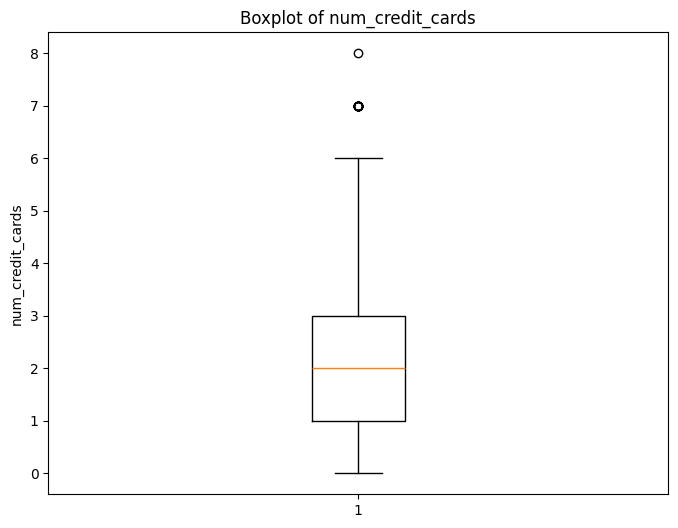

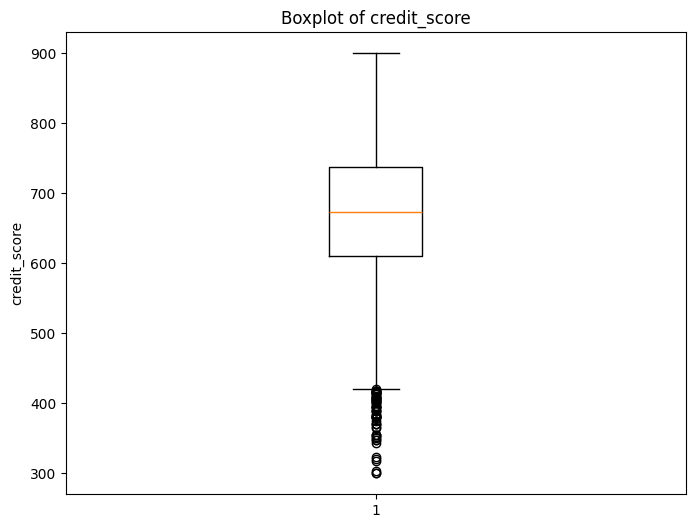

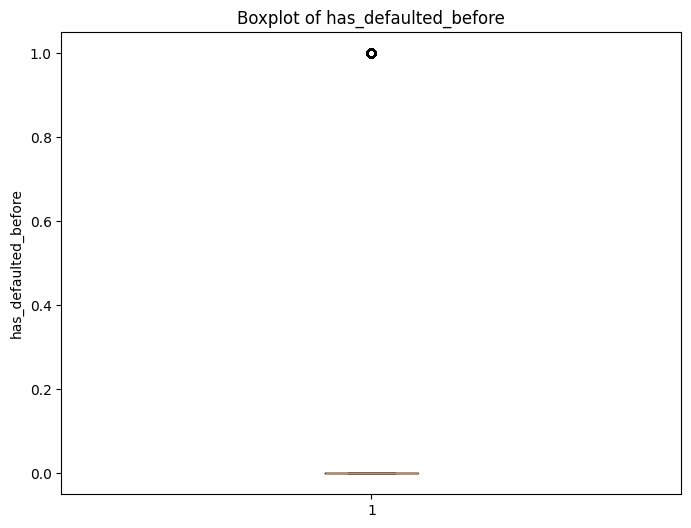

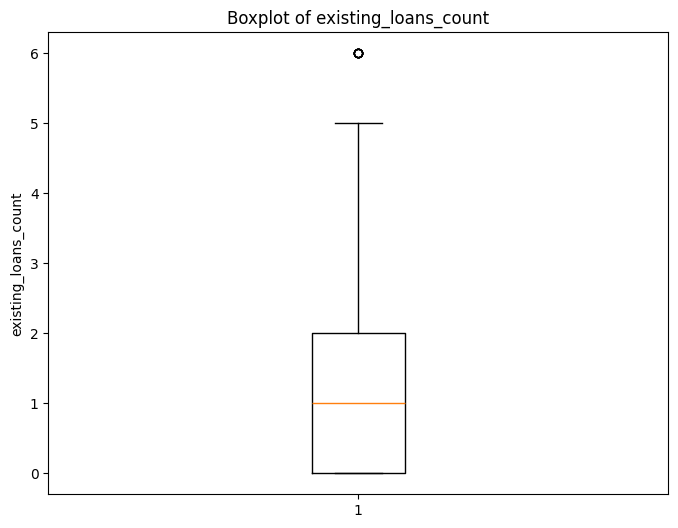

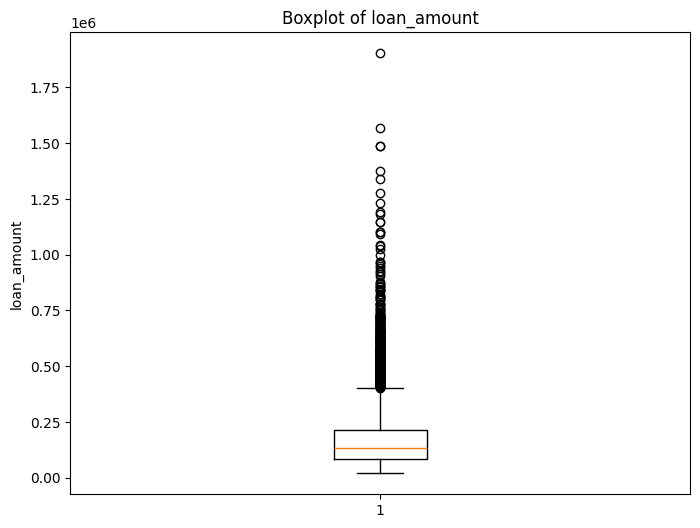

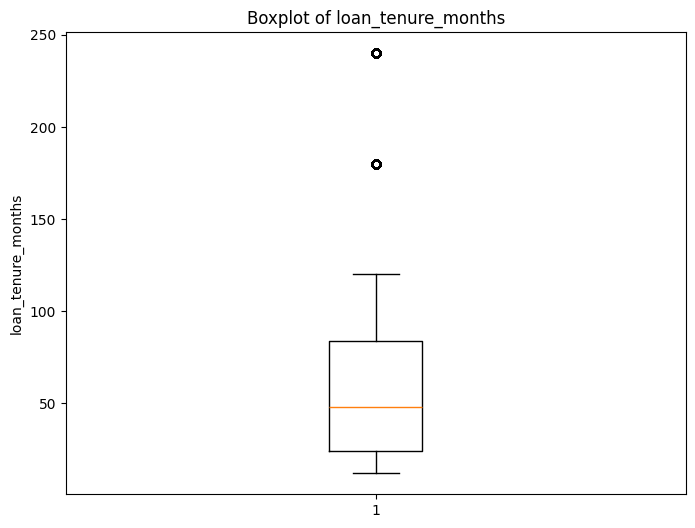

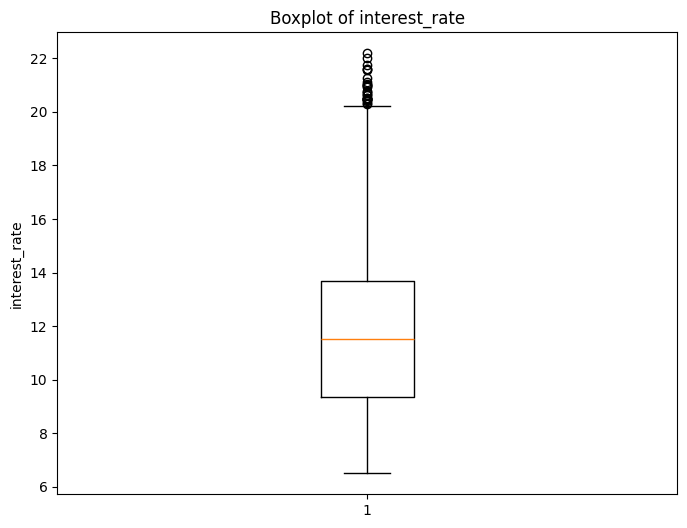

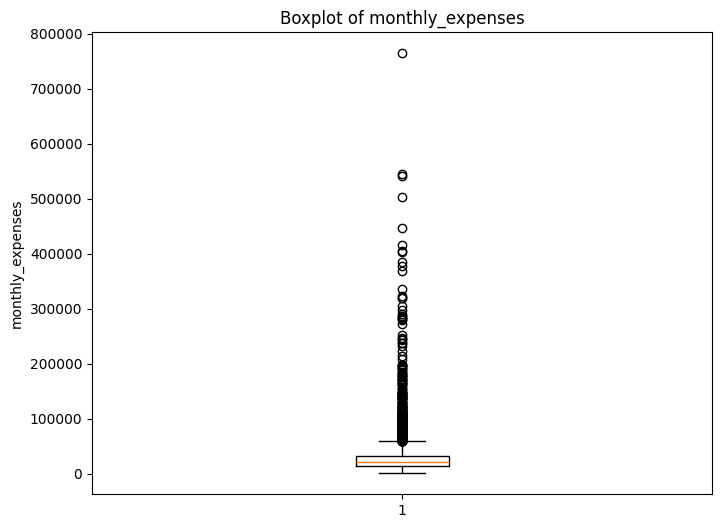

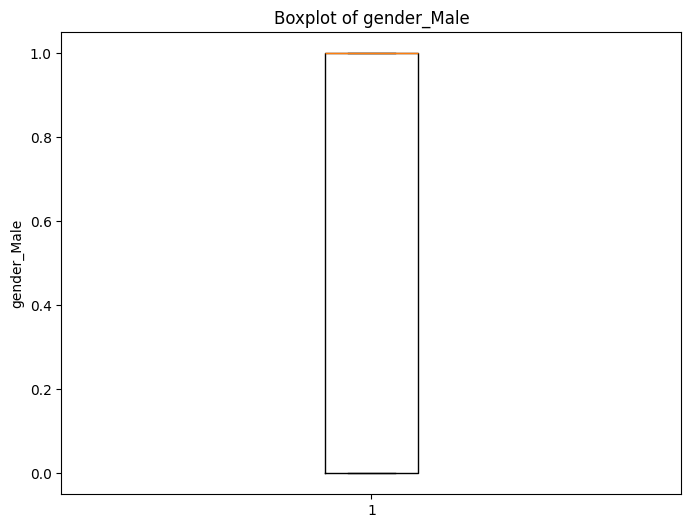

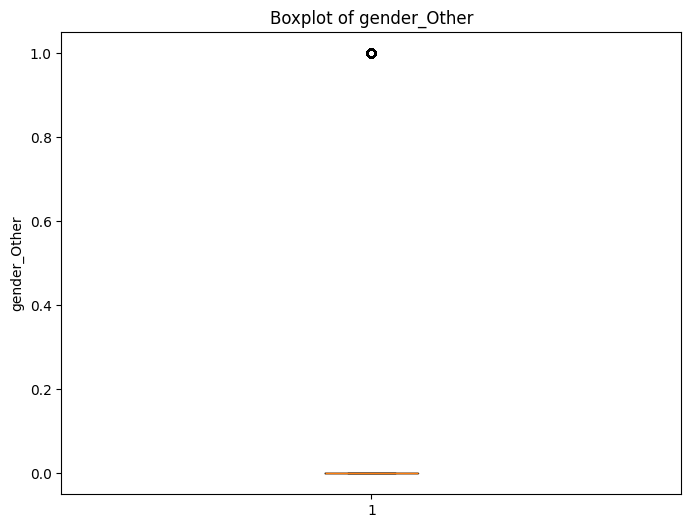

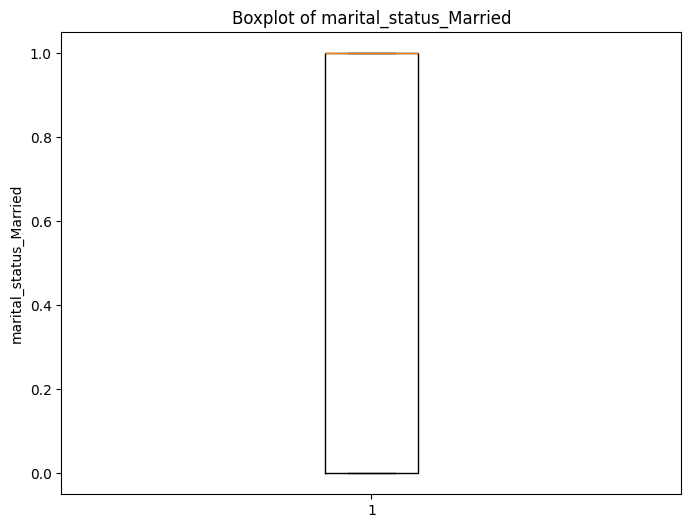

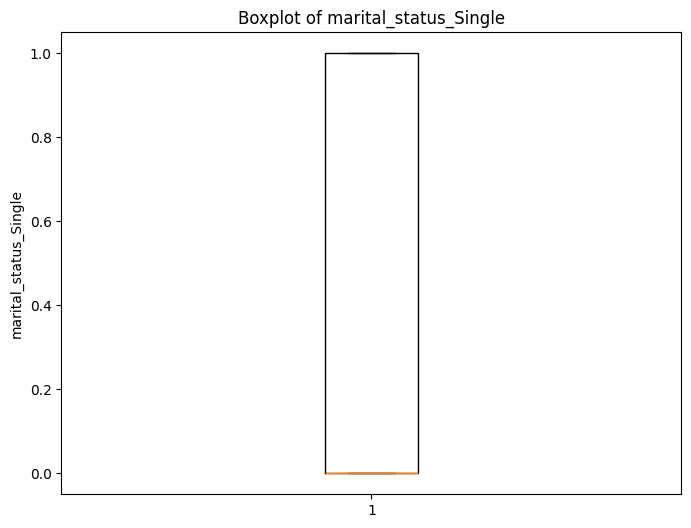

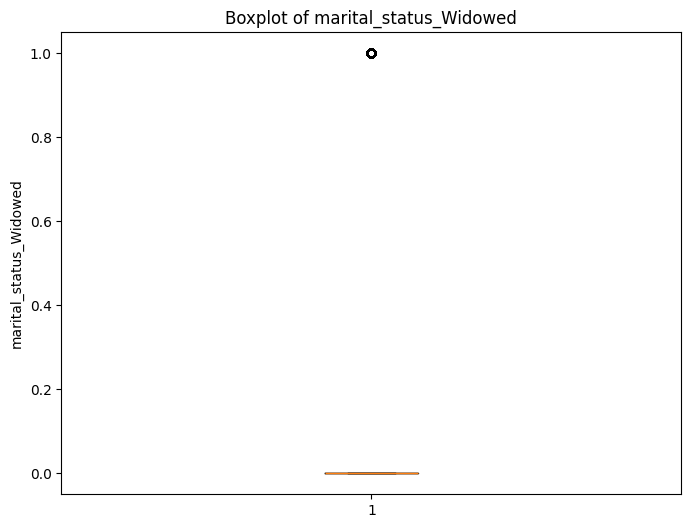

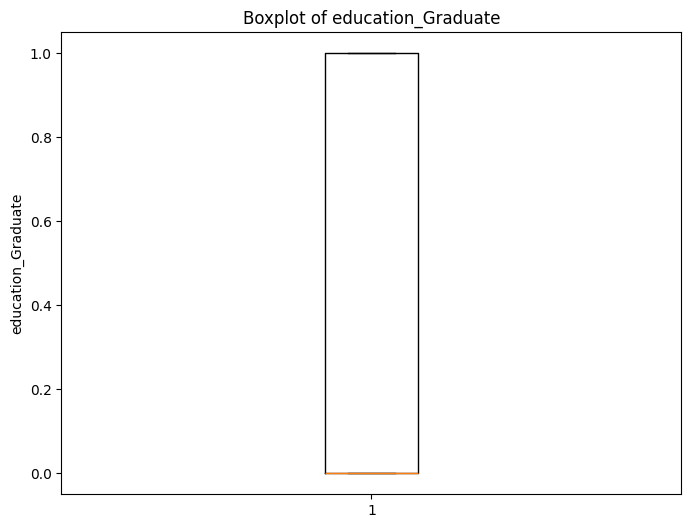

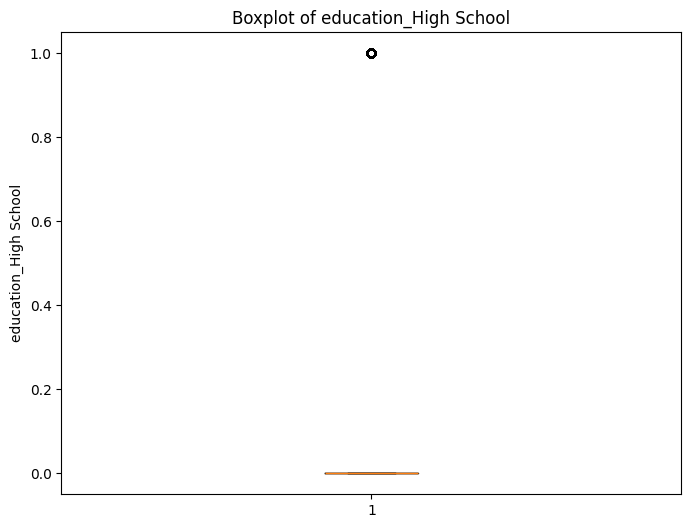

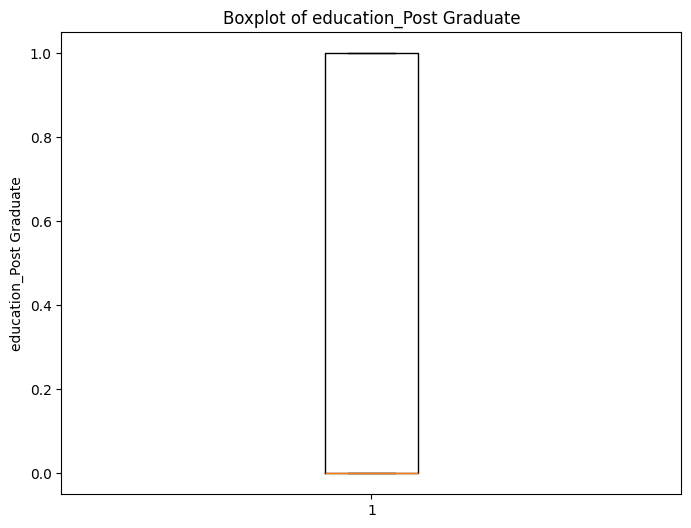

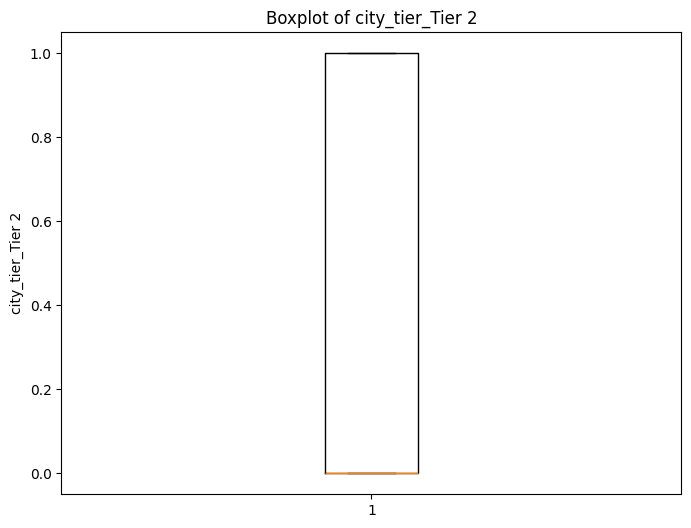

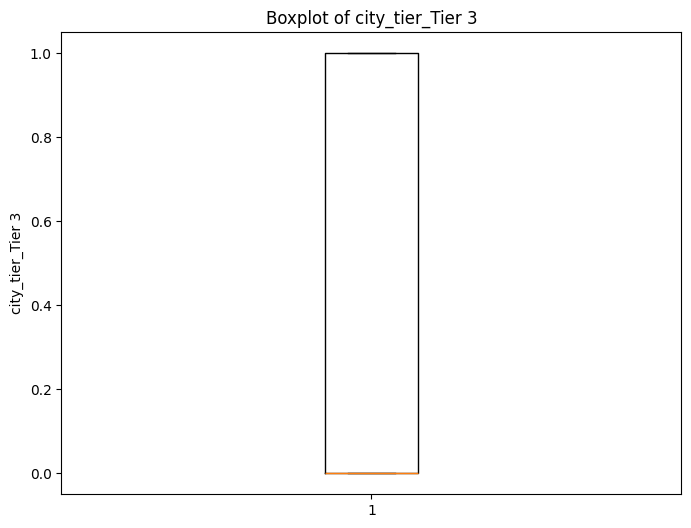

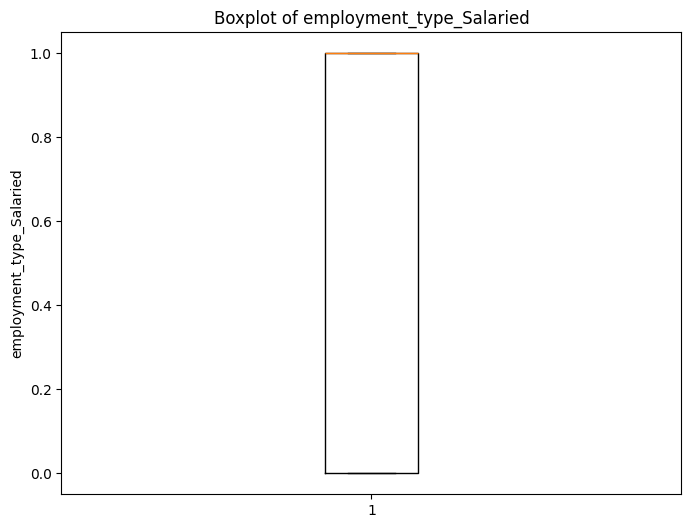

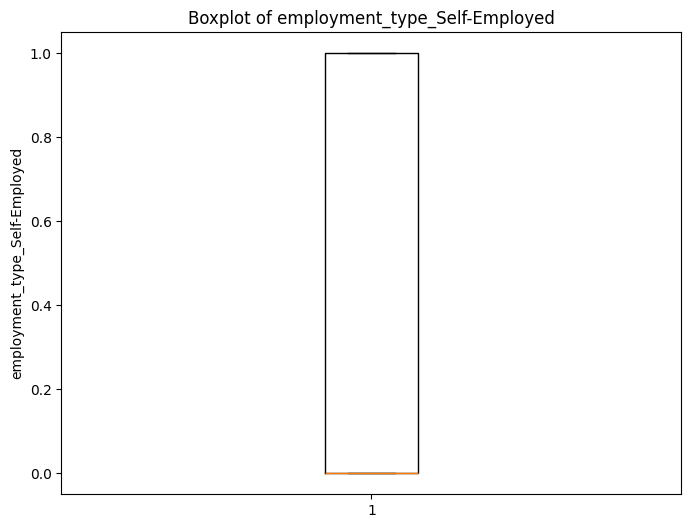

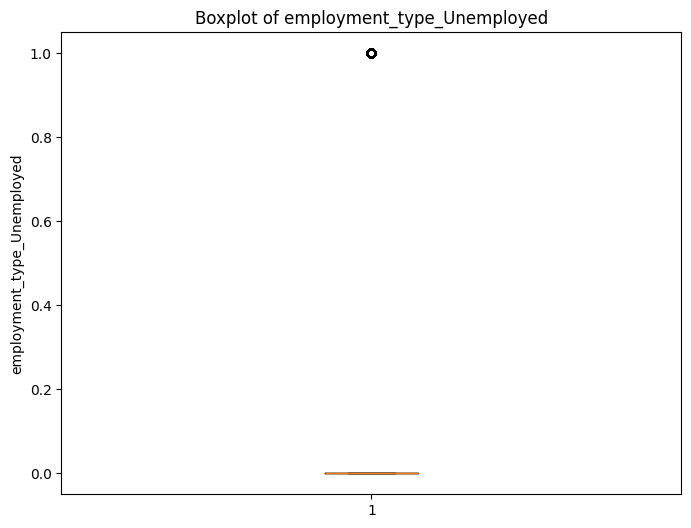

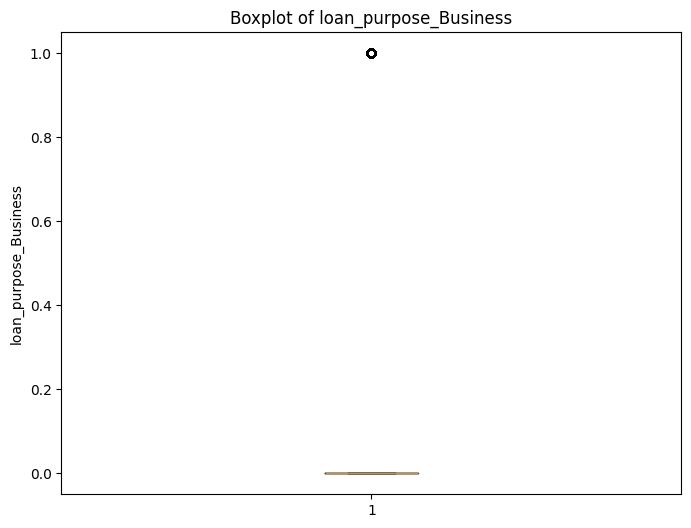

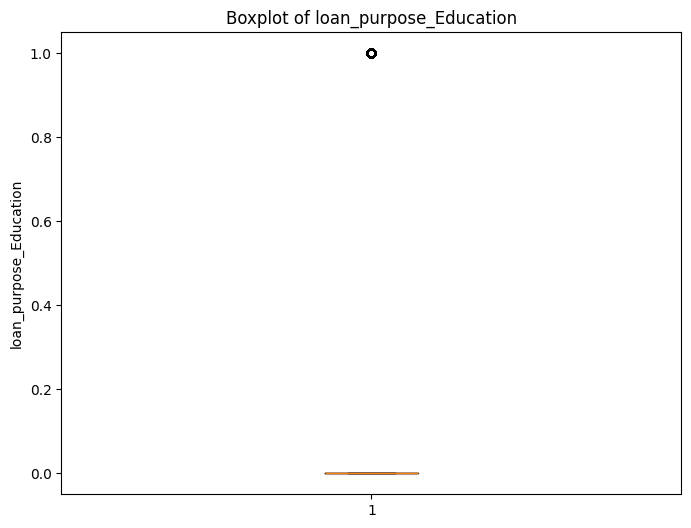

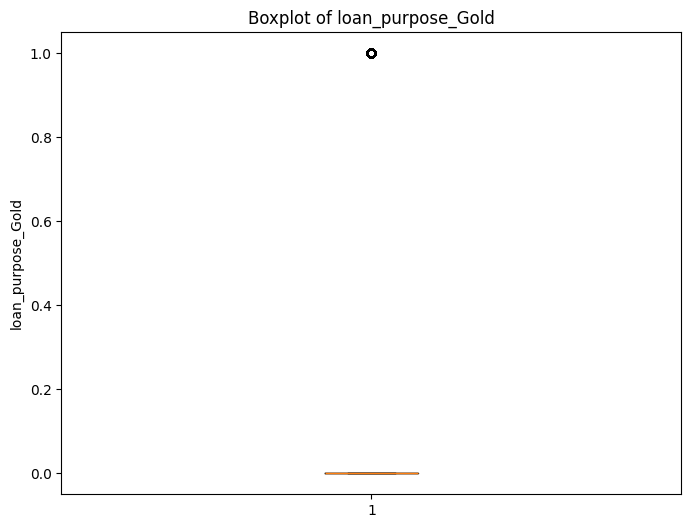

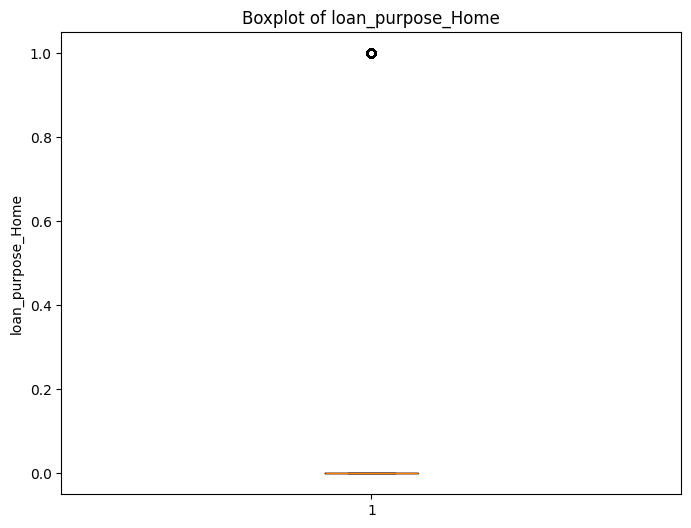

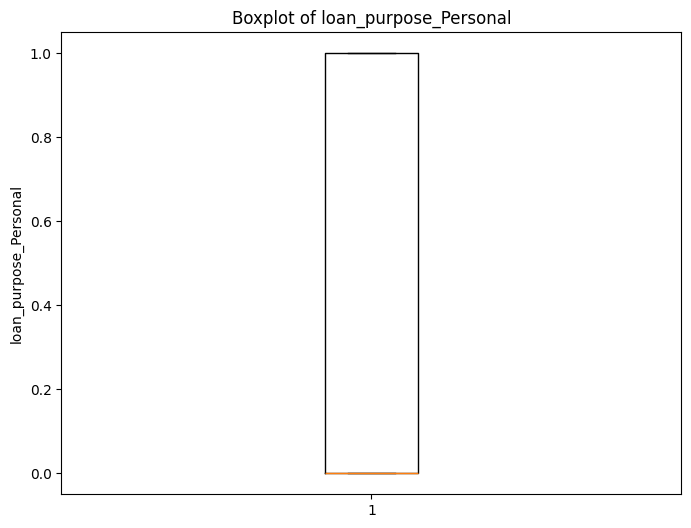

In [90]:
# check outliers in the numerical features using boxplots
import matplotlib.pyplot as plt

for col in x.select_dtypes(include=['int64', 'float64']).columns:
    plt.figure(figsize=(8, 6))
    plt.boxplot(x[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()


In [91]:
# delete outliers using IQR method
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

In [92]:
# scale the numerical features using StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train), columns=x_train.columns)
x_test_scaled = pd.DataFrame(scaler.transform(x_test), columns=x_test.columns)

In [93]:
# check shape of scaled data
print(f"x_train_scaled shape: {x_train_scaled.shape}")
print(f"x_test_scaled shape: {x_test_scaled.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

x_train_scaled shape: (8000, 30)
x_test_scaled shape: (2000, 30)
y_train shape: (8000,)
y_test shape: (2000,)


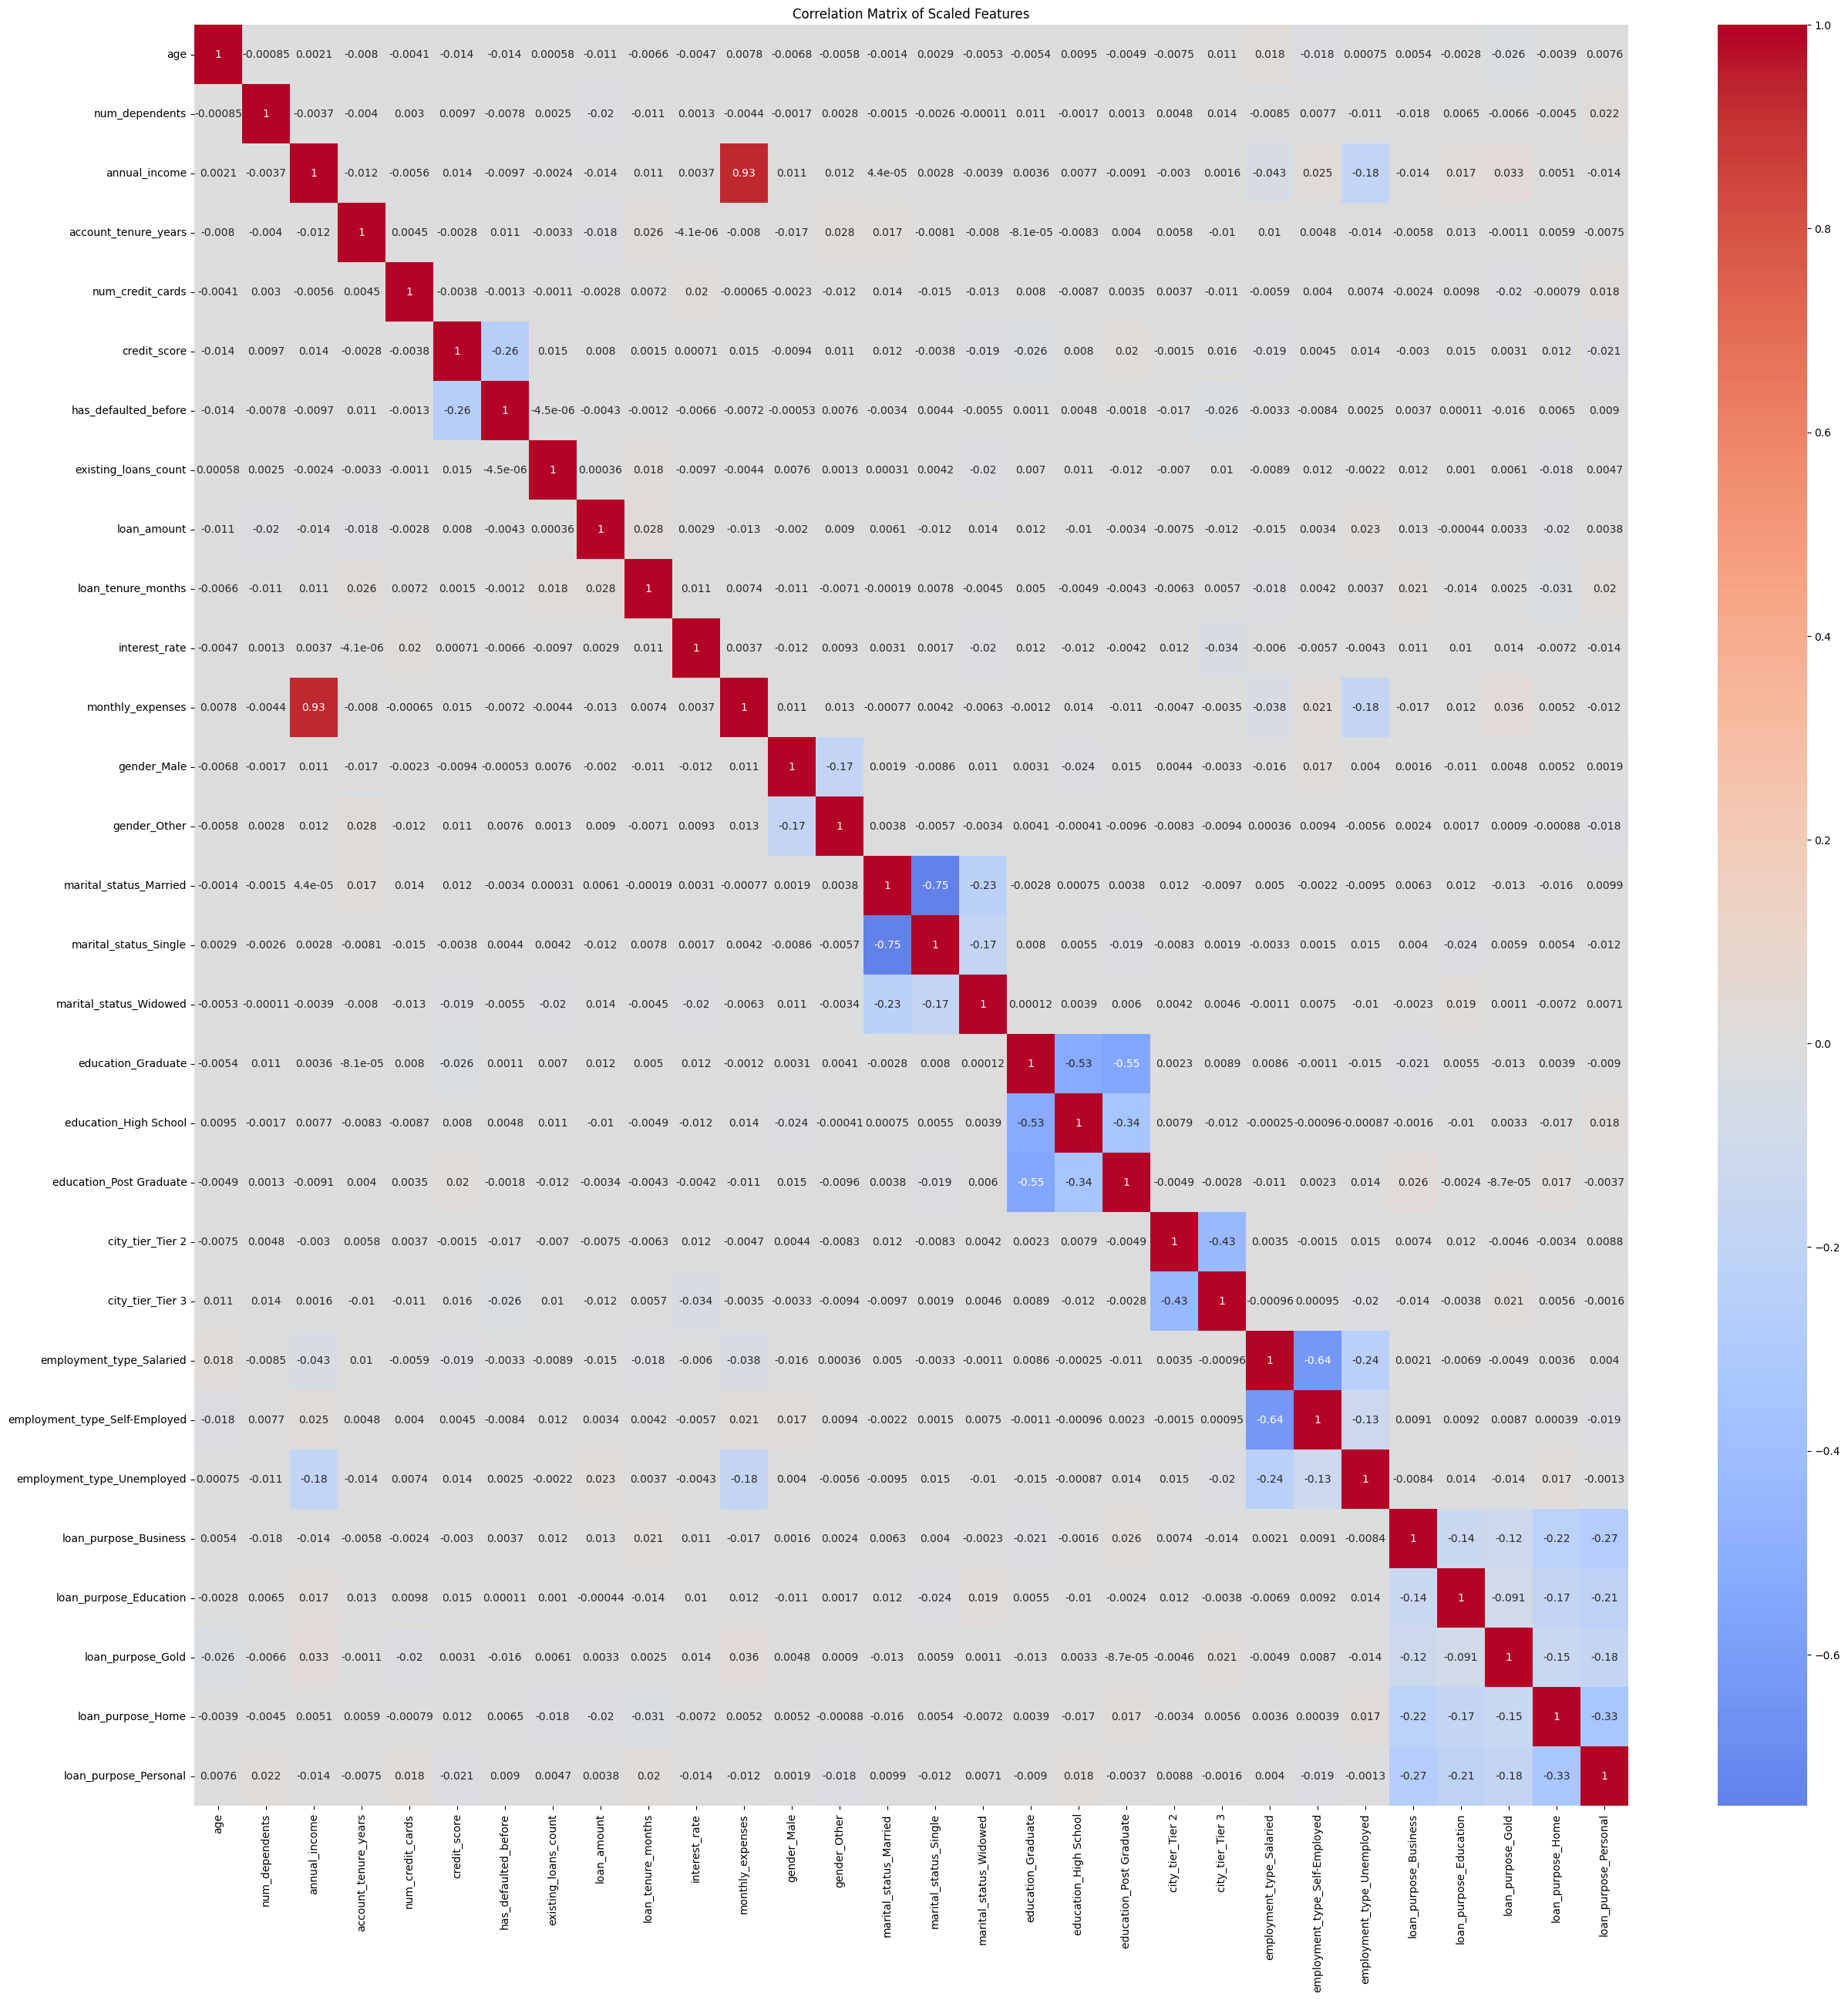

In [94]:
# heatmap of correlation matrix
plt.figure(figsize=(30,30))
sns.heatmap(x_train_scaled.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Scaled Features')
plt.show()

In [95]:
# modelling
import statsmodels.api as sm
x_train_sm = sm.add_constant(x_train_scaled)
x_test_sm = sm.add_constant(x_test_scaled)



In [96]:
logistic_model = sm.Logit(y_train.reset_index(drop=True), x_train_sm.drop(columns=['age',"num_dependents", "account_tenure_years", "education_High School", "gender_Male","marital_status_Single",
                                                                                   
                                                                         "marital_status_Married" , "interest_rate" ,"monthly_expenses" , "loan_purpose_Business","loan_purpose_Personal" ,"loan_purpose_Gold",
                                                                          "loan_purpose_Home" , "employment_type_Salaried","employment_type_Self-Employed","marital_status_Widowed" ,"gender_Other" ,"city_tier_Tier 2" ,"loan_purpose_Education" ]))
result = logistic_model.fit()
result.summary()

Optimization terminated successfully.
         Current function value: 0.418619
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:           loan_default   No. Observations:                 8000
Model:                          Logit   Df Residuals:                     7988
Method:                           MLE   Df Model:                           11
Date:                Wed, 12 Aug 2026   Pseudo R-squ.:                  0.1608
Time:                        18:38:36   Log-Likelihood:                -3349.0
converged:                       True   LL-Null:                       -3990.7
Covariance Type:            nonrobust   LLR p-value:                1.605e-268
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                         -1.6735      0.035    -48.348      0.000      -1.741      -1.606
annual_income                 -0.1258      0.043     -2.924      0.003      -0.210      -0.041
num_credit_cards              -0.0630      0.031     -2.022      0.043      -0.124      -0.002
credit_score                  -0.8034      0.035    -23.121      0.000      -0.872      -0.735
has_defaulted_before           0.3523      0.026     13.772      0.000       0.302       0.402
existing_loans_count           0.0844      0.030      2.774      0.006       0.025       0.144
loan_amount                    0.2386      0.028      8.569      0.000       0.184       0.293
loan_tenure_months            -0.1735      0.033     -5.215      0.000      -0.239      -0.108
education_Graduate             0.0613      0.037      1.650      0.099      -0.012       0.134
education_Post Graduate        0.0120      0.038      0.320      0.749      -0.062       0.086
city_tier_Tier 3               0.0785      0.031      2.570      0.010       0.019       0.138
employment_type_Unemployed     0.3131      0.026     11.899      0.000       0.262       0.365
==============================================================================================
"""

In [97]:
# ✅ Step 1: Check actual column names
print(x_train_sm.columns.tolist())

['const', 'age', 'num_dependents', 'annual_income', 'account_tenure_years', 'num_credit_cards', 'credit_score', 'has_defaulted_before', 'existing_loans_count', 'loan_amount', 'loan_tenure_months', 'interest_rate', 'monthly_expenses', 'gender_Male', 'gender_Other', 'marital_status_Married', 'marital_status_Single', 'marital_status_Widowed', 'education_Graduate', 'education_High School', 'education_Post Graduate', 'city_tier_Tier 2', 'city_tier_Tier 3', 'employment_type_Salaried', 'employment_type_Self-Employed', 'employment_type_Unemployed', 'loan_purpose_Business', 'loan_purpose_Education', 'loan_purpose_Gold', 'loan_purpose_Home', 'loan_purpose_Personal']


In [98]:
# ✅ Step 2: Clean up column names (remove extra spaces)
x_train_sm.columns = x_train_sm.columns.str.strip()
x_test_sm.columns = x_test_sm.columns.str.strip()

In [99]:
drop_to = ["education_Graduate","education_High School","education_Post Graduate", "annual_income" ]

x_train_sm = x_train_sm.drop(columns=drop_to)
x_test_sm = x_test_sm.drop(columns=drop_to)

In [100]:
# vif the p-value is less than 0.05, we can reject the null hypothesis and conclude that the variable is statistically significant in predicting the target variable.
from statsmodels.stats.outliers_influence import variance_inflation_factor

import pandas as pd

vif_df = pd.DataFrame({
    "Feature": x_train_sm.columns,
    "VIF": [variance_inflation_factor(x_train_sm.values, i)
            for i in range(x_train_sm.shape[1])]
})

print(vif_df)

                          Feature       VIF
0                           const  1.000000
1                             age  1.002377
2                  num_dependents  1.002067
3            account_tenure_years  1.003377
4                num_credit_cards  1.002174
5                    credit_score  1.073928
6            has_defaulted_before  1.073900
7            existing_loans_count  1.001906
8                     loan_amount  1.003577
9              loan_tenure_months  1.004554
10                  interest_rate  1.003349
11               monthly_expenses  1.051679
12                    gender_Male  1.032309
13                   gender_Other  1.033253
14         marital_status_Married  3.256340
15          marital_status_Single  3.174494
16         marital_status_Widowed  1.475893
17               city_tier_Tier 2  1.227083
18               city_tier_Tier 3  1.229805
19       employment_type_Salaried  2.089222
20  employment_type_Self-Employed  1.985065
21     employment_type_Unemploye

In [101]:
x_train_sm.shape

(8000, 27)

In [102]:
# Reset indices for both X and y
x_train_sm = x_train_sm.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

In [103]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error , roc_auc_score, accuracy_score, confusion_matrix, classification_report , roc_curve, auc

In [104]:
# Re-fit the model
logit_model = sm.Logit(y_train, x_train_sm)
result = logit_model.fit()

Optimization terminated successfully.
         Current function value: 0.418754
         Iterations 6


In [105]:
y_pred_lr_t = result.predict(x_train_sm)
# Metrics
roc_lr_t = roc_auc_score(y_train, y_pred_lr_t)
print(f"ROC-AUC: {roc_lr_t:.4f}")

ROC-AUC: 0.7657


In [106]:
y_pred_lr = result.predict(x_test_sm)
# Metrics
roc_lr = roc_auc_score(y_test, y_pred_lr)
print(f"ROC-AUC: {roc_lr:.4f}")

ROC-AUC: 0.7368


Optimal Threshold: 0.1891062051093251


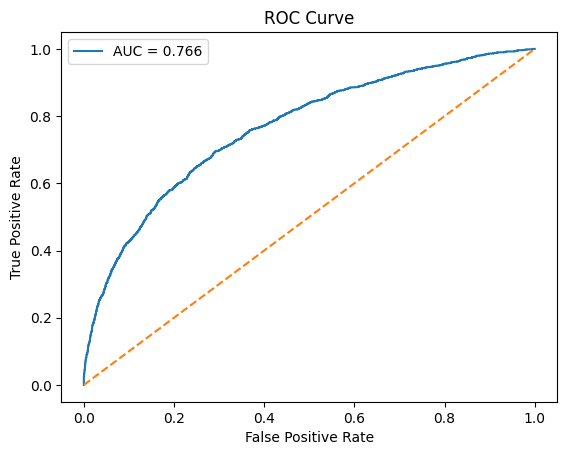

In [107]:
fpr, tpr, thresholds = roc_curve(y_train, y_pred_lr_t)
optimal_threshold = thresholds[np.argmax(tpr - fpr)]
print("Optimal Threshold:", optimal_threshold)
plt.plot(fpr, tpr, label=f"AUC = {roc_lr_t:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [108]:
y_pred_train = (y_pred_lr_t >=optimal_threshold ).astype(int)
y_pred_test = (y_pred_lr >= optimal_threshold).astype(int)

In [109]:
print(classification_report(y_train, y_pred_train))
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.90      0.71      0.79      6409
           1       0.37      0.69      0.48      1591

    accuracy                           0.71      8000
   macro avg       0.64      0.70      0.64      8000
weighted avg       0.80      0.71      0.73      8000

              precision    recall  f1-score   support

           0       0.89      0.71      0.79      1602
           1       0.36      0.63      0.46       398

    accuracy                           0.70      2000
   macro avg       0.62      0.67      0.62      2000
weighted avg       0.78      0.70      0.72      2000



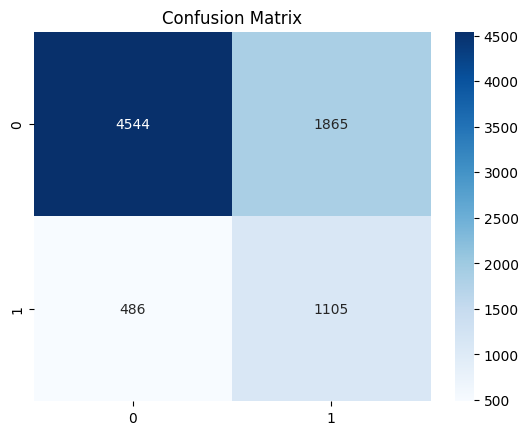

In [110]:
cm = confusion_matrix(y_train, y_pred_train)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [111]:
# tune the logistic regression model using GridSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression


param_grid = {'C': [0.1, 1, 10, 100]}
logit = LogisticRegression()
grid_search = GridSearchCV(logit, param_grid, cv=5)
grid_search.fit(x_train_sm, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter indexes are 

In [112]:
log_reg_cv = LogisticRegression(solver="liblinear", random_state=42)

grid_search = GridSearchCV(
    estimator=log_reg_cv,
    param_grid=param_grid,
    scoring='roc_auc',   # optimize for ROC-AUC (good for imbalanced targets too)
    cv=5,                 # 5-fold cross-validation
    verbose=2
)

In [113]:
grid_search.fit(x_train_scaled, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV] END ..............................................C=0.1; total time=   0.1s
[CV] END ..............................................C=0.1; total time=   0.0s
[CV] END ..............................................C=0.1; total time=   0.0s
[CV] END ..............................................C=0.1; total time=   0.0s
[CV] END ..............................................C=0.1; total time=   0.0s
[CV] END ................................................C=1; total time=   0.0s
[CV] END ................................................C=1; total time=   0.0s
[CV] END ................................................C=1; total time=   0.0s
[CV] END ................................................C=1; total time=   0.0s
[CV] END ................................................C=1; total time=   0.0s
[CV] END ...............................................C=10; total time=   0.0s
[CV] END ........................................

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...r='liblinear')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate paramet

In [114]:
from sklearn.model_selection import GridSearchCV

In [115]:
grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV] END ..............................................C=0.1; total time=   0.1s
[CV] END ..............................................C=0.1; total time=   0.0s
[CV] END ..............................................C=0.1; total time=   0.0s
[CV] END ..............................................C=0.1; total time=   0.0s
[CV] END ..............................................C=0.1; total time=   0.0s
[CV] END ................................................C=1; total time=   0.0s
[CV] END ................................................C=1; total time=   0.0s
[CV] END ................................................C=1; total time=   0.0s
[CV] END ................................................C=1; total time=   0.1s
[CV] END ................................................C=1; total time=   0.0s
[CV] END ...............................................C=10; total time=   0.1s
[CV] END ........................................

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...r='liblinear')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate paramet

In [116]:
print("Best Hyperparameters:", grid_search.best_params_)
print("Best Cross-Validation ROC-AUC:", round(grid_search.best_score_, 4))

Best Hyperparameters: {'C': 0.1}
Best Cross-Validation ROC-AUC: 0.7076


In [117]:
best_lr = grid_search.best_estimator_

In [118]:
y_pred_best = best_lr.predict(x_test_scaled)
y_prob_best = best_lr.predict_proba(x_test_scaled)[:, 1]

In [119]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, classification_report, confusion_matrix



Tuned Logistic Regression Performance:
Accuracy: 0.6025
F1 Score: 0.4115
ROC-AUC: 0.6990

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.58      0.70      1602
           1       0.29      0.70      0.41       398

    accuracy                           0.60      2000
   macro avg       0.59      0.64      0.56      2000
weighted avg       0.77      0.60      0.64      2000



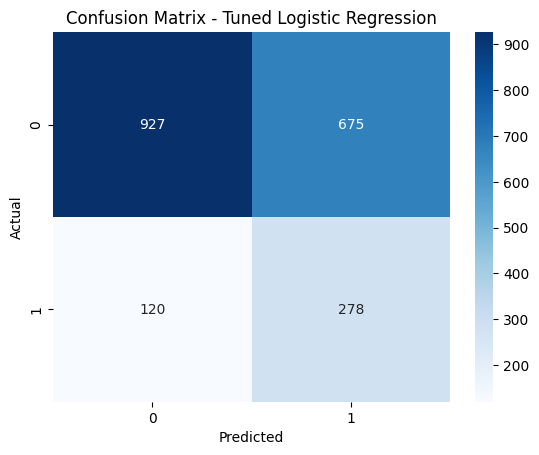

In [120]:
# 6. Evaluate
acc_best = accuracy_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)
roc_best = roc_auc_score(y_test, y_prob_best)

print("\nTuned Logistic Regression Performance:")
print(f"Accuracy: {acc_best:.4f}")
print(f"F1 Score: {f1_best:.4f}")
print(f"ROC-AUC: {roc_best:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

# 7. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Tuned Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [121]:
#

# KNN 

In [122]:
from sklearn.neighbors import KNeighborsClassifier

In [123]:
from sklearn.model_selection import GridSearchCV
knn_params = {"n_neighbors":[3,5,7,9]}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, scoring='roc_auc')
knn_grid.fit(x_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [3, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate paramet

In [124]:
best_knn = knn_grid.best_estimator_
y_pred_knn = best_knn.predict(x_test_scaled)
y_prob_knn = best_knn.predict_proba(x_test_scaled)[:,1]

In [125]:
knn_results = {
    "Accuracy": accuracy_score(y_test, y_pred_knn),
    "F1": f1_score(y_test, y_pred_knn),
    "ROC-AUC": roc_auc_score(y_test, y_prob_knn)
}
print("KNN Results:", knn_results)

KNN Results: {'Accuracy': 0.809, 'F1': 0.22357723577235772, 'ROC-AUC': 0.6403200459224963}


# DESSION TREE

In [126]:
# Decision Tree with GridSearchCV
from sklearn.tree import DecisionTreeClassifier

dt_params = {"max_depth":[3,5,7,10]}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=5, scoring='roc_auc')
dt_grid.fit(x_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate p

In [127]:
best_dt = dt_grid.best_estimator_
y_pred_dt = best_dt.predict(x_test_scaled)
y_prob_dt = best_dt.predict_proba(x_test_scaled)[:,1]

In [128]:
dt_results = {
    "Accuracy": accuracy_score(y_test, y_pred_dt),
    "F1": f1_score(y_test, y_pred_dt),
    "ROC-AUC": roc_auc_score(y_test, y_prob_dt)
}
print("Decision Tree Results:", dt_results)

Decision Tree Results: {'Accuracy': 0.8085, 'F1': 0.2135523613963039, 'ROC-AUC': 0.7058780168006071}


# RANDOM FOREST


In [129]:
# Random Forest with GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf_params = {"n_estimators":[50,100,200], "max_depth":[5,10,None]}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring='roc_auc')
rf_grid.fit(x_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displaye

In [130]:
best_rf = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(x_test_scaled)
y_prob_rf = best_rf.predict_proba(x_test_scaled)[:,1]

In [131]:
rf_results = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "F1": f1_score(y_test, y_pred_rf),
    "ROC-AUC": roc_auc_score(y_test, y_prob_rf)
}
print("Random Forest Results:", rf_results)

Random Forest Results: {'Accuracy': 0.816, 'F1': 0.25203252032520324, 'ROC-AUC': 0.7367580725098651}


In [132]:
# Combine all results into summary DataFrame
results = {
    "KNN": knn_results,
    "DecisionTree": dt_results,
    "RandomForest": rf_results
}

summary_df = pd.DataFrame(results).T.sort_values(by="ROC-AUC", ascending=False)
print(summary_df)


              Accuracy        F1   ROC-AUC
RandomForest    0.8160  0.252033  0.736758
DecisionTree    0.8085  0.213552  0.705878
KNN             0.8090  0.223577  0.640320


In [135]:
import joblib
from sklearn.ensemble import RandomForestClassifier

# Retrain with balanced class weights to fix the F1 score!
rf_model = RandomForestClassifier(class_weight="balanced", random_state=42)
rf_model.fit(x_train, y_train)

# Save the trained model file
joblib.dump(rf_model, "model.joblib")
print("✅ High-F1 Random Forest model saved successfully!")

✅ High-F1 Random Forest model saved successfully!
